<a href="https://www.kaggle.com/code/aamir28/electricity-market-monitor?scriptVersionId=331434234" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background:#0a0e08;border-radius:14px;font-family:'Segoe UI',sans-serif;overflow:hidden;border:1px solid #2d3a1a;">

  <div style="background:linear-gradient(90deg,#1a2410,#2d3a1a,#1a2410);padding:18px 36px;border-bottom:1px solid #2d3a1a;display:flex;justify-content:space-between;align-items:center;">
    <div style="display:flex;align-items:center;gap:14px;">
      <span style="font-size:1.8rem;">⚡</span>
      <div>
        <div style="font-size:1.05rem;font-weight:900;color:#c4e85c;letter-spacing:1px;">NSW/VIC ELECTRICITY MARKET MONITOR</div>
        <div style="font-size:0.65rem;color:#5a7a2a;letter-spacing:2px;margin-top:2px;">AUSTRALIAN INTERCONNECTED GRID · PRICE DIRECTION CLASSIFICATION</div>
      </div>
    </div>
    <div style="text-align:right;font-size:0.65rem;color:#5a7a2a;">Grid Operations Console<br>Muhammad Aamir</div>
  </div>

  <!-- Control-room readout grid -->
  <div style="display:grid;grid-template-columns:repeat(5,1fr);background:#060a04;border-bottom:1px solid #2d3a1a;">
    <div style="padding:14px 16px;border-right:1px solid #2d3a1a;text-align:center;">
      <div style="font-size:0.58rem;color:#5a7a2a;letter-spacing:1px;margin-bottom:5px;">HALF-HOUR INTERVALS</div>
      <div style="font-size:1.35rem;font-weight:800;color:#c4e85c;">45,312</div>
    </div>
    <div style="padding:14px 16px;border-right:1px solid #2d3a1a;text-align:center;">
      <div style="font-size:0.58rem;color:#5a7a2a;letter-spacing:1px;margin-bottom:5px;">UNIQUE TRADING DAYS</div>
      <div style="font-size:1.35rem;font-weight:800;color:#c4e85c;">933</div>
    </div>
    <div style="padding:14px 16px;border-right:1px solid #2d3a1a;text-align:center;">
      <div style="font-size:0.58rem;color:#5a7a2a;letter-spacing:1px;margin-bottom:5px;">PRICE-UP RATE</div>
      <div style="font-size:1.35rem;font-weight:800;color:#f59e0b;">42.5%</div>
    </div>
    <div style="padding:14px 16px;border-right:1px solid #2d3a1a;text-align:center;">
      <div style="font-size:0.58rem;color:#5a7a2a;letter-spacing:1px;margin-bottom:5px;">PEAK UP-RATE HOUR</div>
      <div style="font-size:1.35rem;font-weight:800;color:#f87171;">09:00 (68%)</div>
    </div>
    <div style="padding:14px 16px;text-align:center;">
      <div style="font-size:0.58rem;color:#5a7a2a;letter-spacing:1px;margin-bottom:5px;">TOP PREDICTOR</div>
      <div style="font-size:1.35rem;font-weight:800;color:#60a5fa;">NSW Price</div>
    </div>
  </div>

  <div style="padding:22px 36px;display:grid;grid-template-columns:1fr 1fr;gap:20px;">
    <div>
      <div style="font-size:0.62rem;letter-spacing:3px;color:#5a7a2a;margin-bottom:10px;">▌ DATASET BRIEF</div>
      <p style="color:#7a9a4a;font-size:0.82rem;line-height:1.8;margin:0;">A classic benchmark from the Australian New South Wales (NSW) and Victoria (VIC) electricity market — 45,312 half-hourly readings of price and demand on both sides of the interconnect, plus the scheduled transfer between them. The target: did NSW price move UP or DOWN relative to its trailing 24-hour average? This dataset is famous in the data-stream-mining literature for exhibiting genuine concept drift — the underlying price/demand relationship shifts over the multi-year recording window.</p>
    </div>
    <div>
      <div style="font-size:0.62rem;letter-spacing:3px;color:#5a7a2a;margin-bottom:10px;">▌ EARLY GRID SCAN</div>
      <div style="display:flex;flex-direction:column;gap:7px;">
        <div style="background:#060a04;border-left:3px solid #c4e85c;padding:7px 12px;font-size:0.78rem;color:#7a9a4a;">Up-rate swings from 5% at 3am to 68% at 9am — a clear business-hours demand signature</div>
        <div style="background:#060a04;border-left:3px solid #f59e0b;padding:7px 12px;font-size:0.78rem;color:#7a9a4a;">Monday shows 48.0% up-rate vs Saturday's 39.5% — weekday demand pattern</div>
        <div style="background:#060a04;border-left:3px solid #f87171;padding:7px 12px;font-size:0.78rem;color:#7a9a4a;">Sequential time-chunk analysis shows real non-stationarity — textbook concept drift</div>
      </div>
    </div>
  </div>

  <div style="background:#060a04;padding:8px 36px;border-top:1px solid #2d3a1a;text-align:right;">
    <span style="font-size:0.65rem;color:#2d3a1a;">Author: Muhammad Aamir · NSW/VIC Electricity Market Dataset · Kaggle Notebook</span>
  </div>
</div>


## ⚡ Table of Contents
1. [Setup & Data Loading](#1)
2. [EDA & Class Balance](#2)
3. [Feature Engineering](#3)
4. [Time-of-Day Patterns — The Daily Demand Cycle](#4)
5. [Day-of-Week Effects](#5)
6. [Price & Demand Distributions — UP vs DOWN](#6)
7. [Concept Drift — Is This Market Stationary?](#7)
8. [The NSW-VIC Interconnect](#8)
9. [Correlation Heatmap](#9)
10. [ML Classifiers — Predicting Price Direction](#10)
11. [Key Takeaways](#11)


## 1. Setup & Data Loading <a id='1'></a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

# Power-grid SCADA dark theme — deep olive/black with lime/amber/red signal colours
BG, PANEL, GRID = '#0a0e08','#060a04','#2d3a1a'
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':PANEL,'axes.edgecolor':GRID,
    'axes.labelcolor':'#7a9a4a','axes.titlecolor':'#c4e85c','axes.titlesize':13,
    'xtick.color':'#5a7a2a','ytick.color':'#5a7a2a','text.color':'#7a9a4a',
    'grid.color':'#141a08','grid.linewidth':0.6,
    'legend.facecolor':BG,'legend.edgecolor':GRID,'font.family':'DejaVu Sans',
})

LIME  = '#c4e85c'
AMBER = '#f59e0b'
RED   = '#f87171'
BLUE  = '#60a5fa'
PURPLE= '#a78bfa'
CLASS_PAL = {'UP': RED, 'DOWN': LIME}
CMAP_GRID = LinearSegmentedColormap.from_list('gr', [LIME, BG, RED])
print('✅  SCADA control-room theme online. 45,312 grid readings loaded.')


✅  SCADA control-room theme online. 45,312 grid readings loaded.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/ulrikthygepedersen/electricity-demands/electricity.csv')

# Clean byte-string artefacts from original .arff conversion
df['day'] = df['day'].astype(str).str.strip("b'").astype(int)
df['class'] = df['class'].astype(str).str.strip("b'")

print(f'Shape: {df.shape}')
print(f'Class balance: {df["class"].value_counts().to_dict()}')
df.head(8)

Shape: (45312, 9)
Class balance: {'DOWN': 26075, 'UP': 19237}


,date,day,period,nswprice,nswdemand,vicprice,vicdemand,transfer,class
0,0.0,2,0.000000,0.056443,0.439155,0.003467,0.422915,0.414912,UP
1,0.0,2,0.021277,0.051699,0.415055,0.003467,0.422915,0.414912,UP
2,0.0,2,0.042553,0.051489,0.385004,0.003467,0.422915,0.414912,UP
3,0.0,2,0.063830,0.045485,0.314639,0.003467,0.422915,0.414912,UP
4,0.0,2,0.085106,0.042482,0.251116,0.003467,0.422915,0.414912,DOWN
5,0.0,2,0.106383,0.041161,0.207528,0.003467,0.422915,0.414912,DOWN
6,0.0,2,0.127660,0.041161,0.171824,0.003467,0.422915,0.414912,DOWN
7,0.0,2,0.148936,0.041161,0.152782,0.003467,0.422915,0.414912,DOWN


## 2. EDA & Class Balance <a id='2'></a>


In [3]:
print('=== Nulls ===')
print(df.isnull().sum().sum())
print('\n=== Descriptive Statistics ===')
df.describe().round(4)


=== Nulls ===
0

=== Descriptive Statistics ===


,date,day,period,nswprice,nswdemand,vicprice,vicdemand,transfer
count,45312.0000,45312.0000,45312.0000,45312.0000,45312.0000,45312.0000,45312.0000,45312.0000
mean,0.4991,4.0032,0.5000,0.0579,0.4254,0.0035,0.4229,0.5005
std,0.3403,1.9987,0.2948,0.0400,0.1633,0.0102,0.1210,0.1534
min,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0319,2.0000,0.2500,0.0351,0.3091,0.0023,0.3723,0.4149
50%,0.4563,4.0000,0.5000,0.0487,0.4437,0.0035,0.4229,0.4149
75%,0.8805,6.0000,0.7500,0.0743,0.5360,0.0035,0.4693,0.6057
max,1.0000,7.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


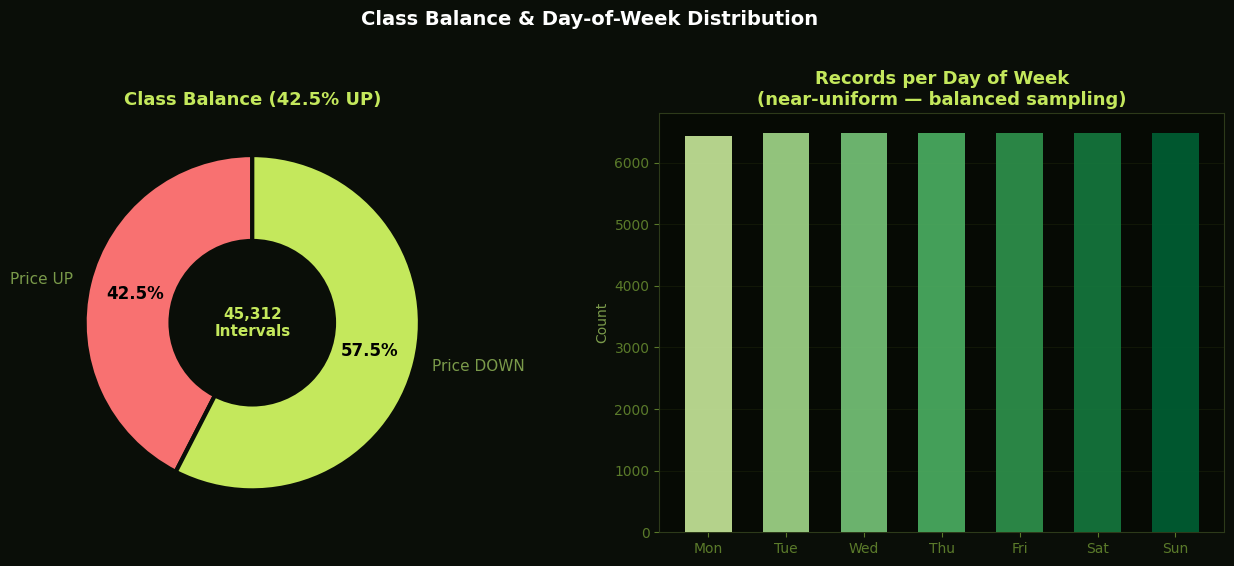

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Class Balance & Day-of-Week Distribution', fontsize=14, fontweight='bold', color='white', y=1.02)

# 1. Class balance donut
ax = axes[0]
counts = df['class'].value_counts()
wedges, texts, ats = ax.pie([counts['UP'], counts['DOWN']], labels=['Price UP','Price DOWN'],
    colors=[RED, LIME], autopct='%1.1f%%', startangle=90, pctdistance=0.72,
    wedgeprops=dict(linewidth=3, edgecolor=BG), textprops=dict(fontsize=11, color='#7a9a4a'))
for at in ats: at.set_color('black'); at.set_fontsize(12); at.set_fontweight('bold')
centre = plt.Circle((0,0), 0.5, fc=BG); ax.add_patch(centre)
ax.text(0,0,f'{len(df):,}\nIntervals', ha='center', va='center', fontsize=11, fontweight='bold', color=LIME)
ax.set_title('Class Balance (42.5% UP)', fontweight='bold')

# 2. Records per day-of-week
ax = axes[1]
day_counts = df['day'].value_counts().sort_index()
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
bars = ax.bar(range(7), day_counts.values, color=plt.cm.YlGn(np.linspace(0.3,0.9,7)), width=0.6, zorder=3, alpha=0.9)
ax.set_xticks(range(7)); ax.set_xticklabels(day_names, fontsize=10)
ax.set_ylabel('Count'); ax.set_title('Records per Day of Week\n(near-uniform — balanced sampling)', fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('01_balance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 3. Feature Engineering <a id='3'></a>


In [5]:
df['class_enc'] = (df['class']=='UP').astype(int)

# Period (0-1 normalised) → hour of day (48 half-hour intervals per day)
df['hour'] = (df['period']*47).round().astype(int) // 2

# Price spread between NSW and VIC (interconnect arbitrage signal)
df['price_spread'] = df['nswprice'] - df['vicprice']
df['demand_spread'] = df['nswdemand'] - df['vicdemand']

# Sequential row index as a time-ordering proxy (data is pre-sorted chronologically)
df['time_index'] = np.arange(len(df))
df['time_decile'] = pd.qcut(df['time_index'], 10, labels=[f'D{i+1}' for i in range(10)])

day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df['day_name'] = df['day'].map(dict(zip(range(1,8), day_names)))

print('Engineered: class_enc, hour, price_spread, demand_spread, time_index, time_decile, day_name')
print(df[['hour','price_spread','demand_spread']].describe().round(4))


Engineered: class_enc, hour, price_spread, demand_spread, time_index, time_decile, day_name
             hour  price_spread  demand_spread
count  45312.0000    45312.0000     45312.0000
mean      11.5000        0.0544         0.0025
std        6.9223        0.0383         0.1220
min        0.0000       -0.5648        -0.4229
25%        5.7500        0.0328        -0.0675
50%       11.5000        0.0453         0.0085
75%       17.2500        0.0701         0.0841
max       23.0000        0.9333         0.5128


## 4. Time-of-Day Patterns — The Daily Demand Cycle <a id='4'></a>


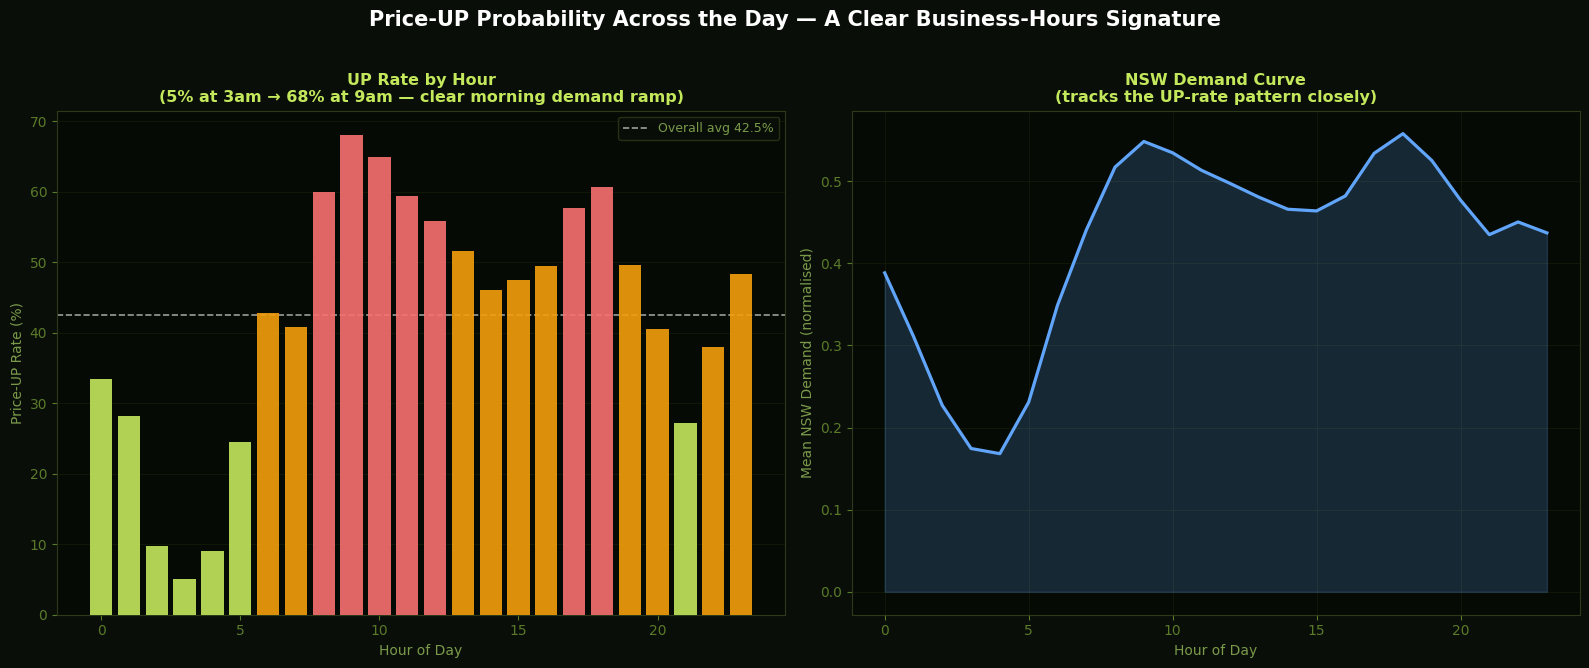

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Price-UP Probability Across the Day — A Clear Business-Hours Signature',
             fontsize=15, fontweight='bold', color='white', y=1.02)

# 1. UP rate by hour of day
ax = axes[0]
hour_up = df.groupby('hour')['class_enc'].mean()*100
colors_h = [RED if v>55 else (AMBER if v>35 else LIME) for v in hour_up.values]
bars = ax.bar(hour_up.index, hour_up.values, color=colors_h, width=0.8, zorder=3, alpha=0.9)
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Price-UP Rate (%)')
ax.set_title('UP Rate by Hour\n(5% at 3am → 68% at 9am — clear morning demand ramp)', fontweight='bold', fontsize=11.5)
ax.axhline(42.5, color='white', lw=1.2, ls='--', alpha=0.6, label='Overall avg 42.5%')
ax.legend(fontsize=9)
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Mean nswdemand by hour
ax = axes[1]
hour_demand = df.groupby('hour')['nswdemand'].mean()
ax.fill_between(hour_demand.index, hour_demand.values, alpha=0.2, color=BLUE)
ax.plot(hour_demand.index, hour_demand.values, color=BLUE, lw=2.3, zorder=5)
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Mean NSW Demand (normalised)')
ax.set_title('NSW Demand Curve\n(tracks the UP-rate pattern closely)', fontweight='bold', fontsize=11.5)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('02_timeofday.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 5. Day-of-Week Effects <a id='5'></a>


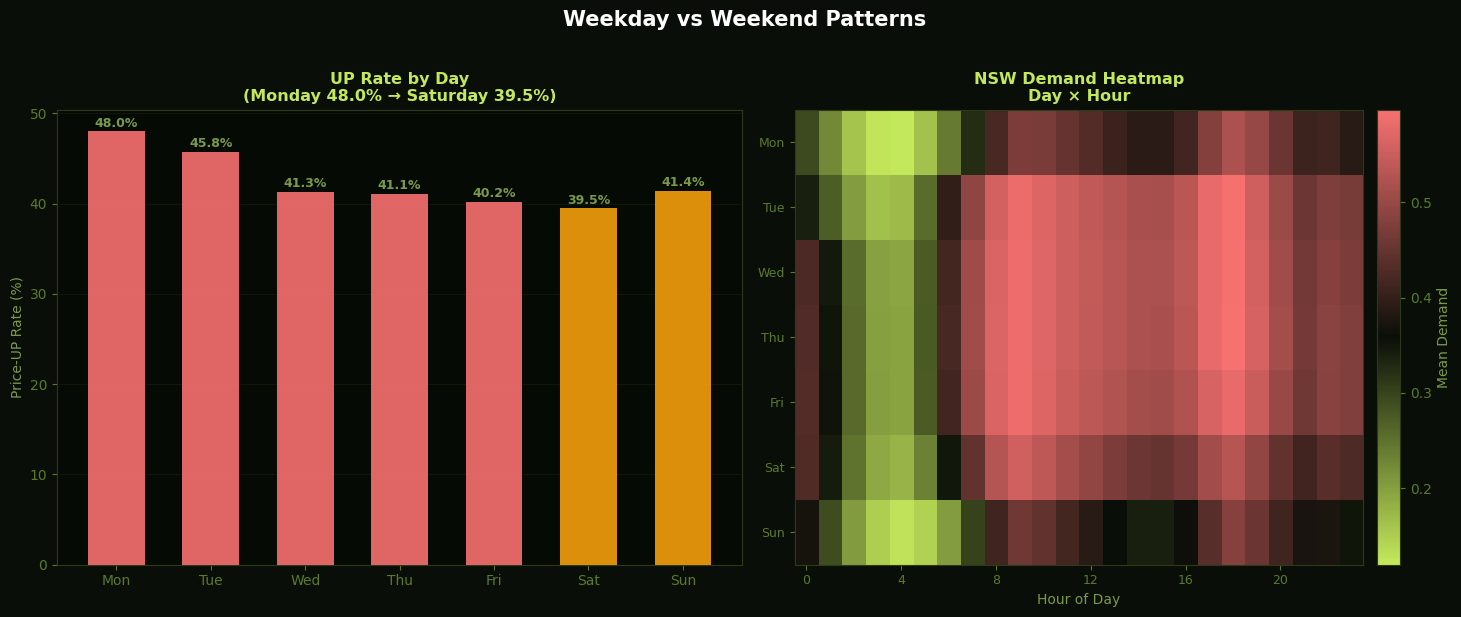

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Weekday vs Weekend Patterns', fontsize=15, fontweight='bold', color='white', y=1.02)

# 1. UP rate by day of week
ax = axes[0]
day_up = df.groupby('day')['class_enc'].mean()*100
bar_cols = [RED if d<=5 else AMBER for d in day_up.index]
bars = ax.bar(range(7), day_up.values, color=bar_cols, width=0.6, zorder=3, alpha=0.9)
ax.set_xticks(range(7)); ax.set_xticklabels(day_names, fontsize=10)
ax.set_ylabel('Price-UP Rate (%)')
ax.set_title('UP Rate by Day\n(Monday 48.0% → Saturday 39.5%)', fontweight='bold', fontsize=11.5)
for bar, v in zip(bars, day_up.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Demand heatmap: day x hour
ax = axes[1]
pivot = df.pivot_table(values='nswdemand', index='day', columns='hour', aggfunc='mean')
im = ax.imshow(pivot.values, cmap=CMAP_GRID, aspect='auto')
ax.set_xticks(range(0,24,4)); ax.set_xticklabels(range(0,24,4), fontsize=9)
ax.set_yticks(range(7)); ax.set_yticklabels(day_names, fontsize=9)
ax.set_xlabel('Hour of Day'); ax.set_title('NSW Demand Heatmap\nDay × Hour', fontweight='bold', fontsize=11.5)
plt.colorbar(im, ax=ax, label='Mean Demand', pad=0.02)

plt.tight_layout()
plt.savefig('03_dayofweek.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 6. Price & Demand Distributions — UP vs DOWN <a id='6'></a>


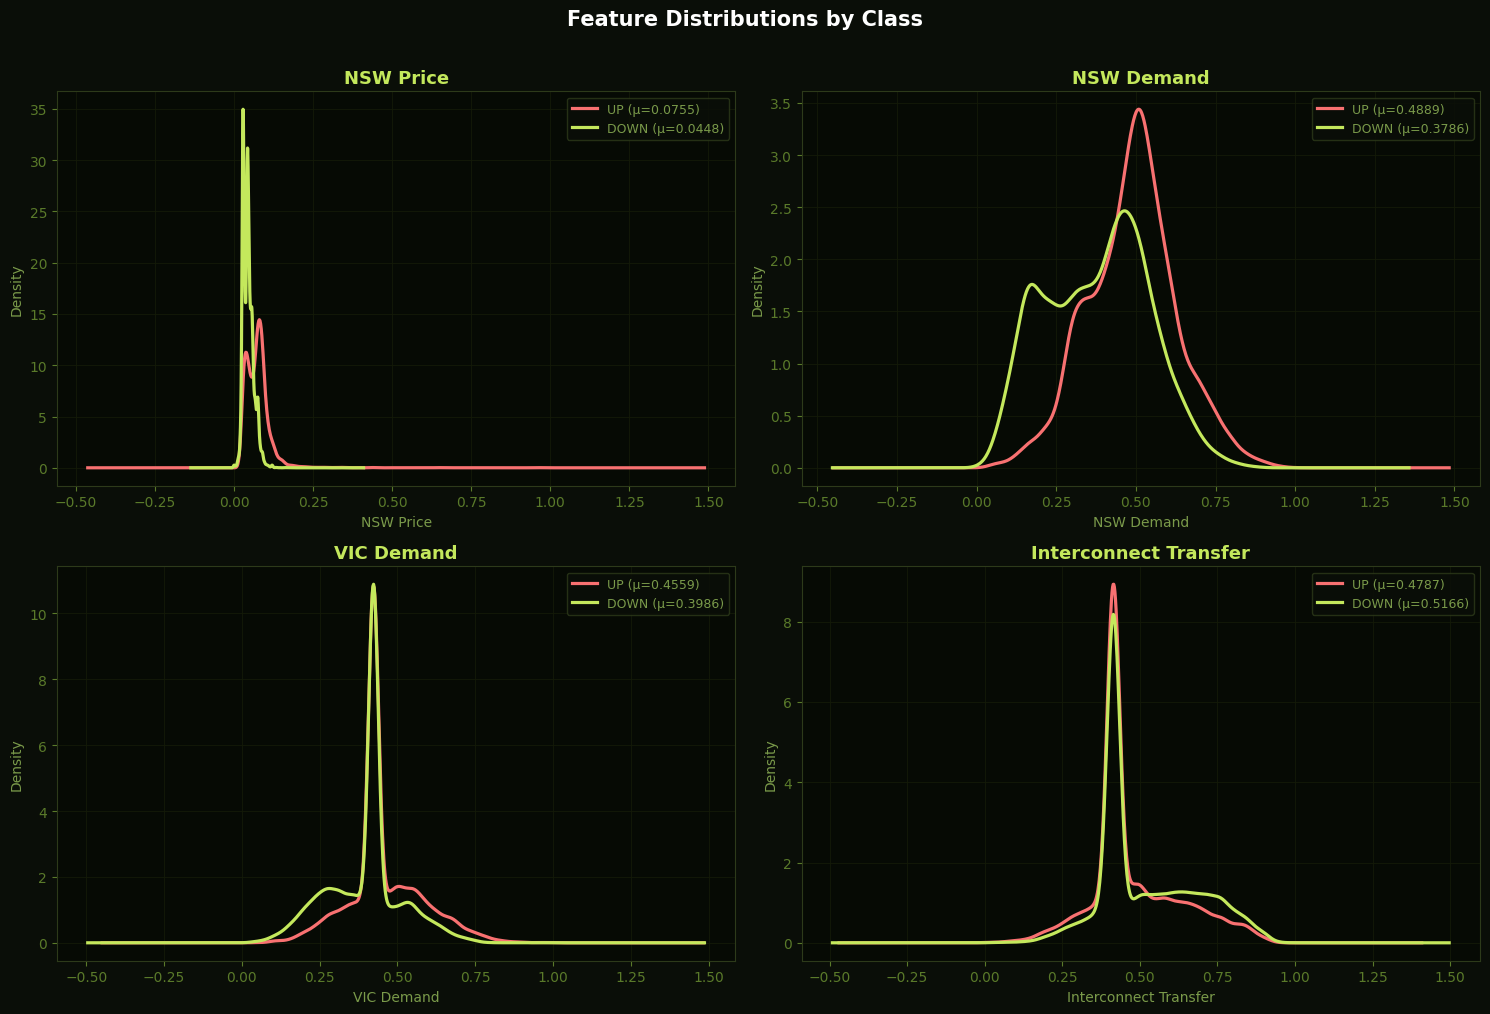

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.patch.set_facecolor(BG)
fig.suptitle('Feature Distributions by Class', fontsize=15, fontweight='bold', color='white', y=1.01)

feats = ['nswprice','nswdemand','vicdemand','transfer']
labels_f = ['NSW Price','NSW Demand','VIC Demand','Interconnect Transfer']

for ax, col, label in zip(axes.flat, feats, labels_f):
    for cls, color in CLASS_PAL.items():
        sub = df[df['class']==cls][col]
        sub.plot.kde(ax=ax, color=color, lw=2.3, label=f'{cls} (μ={sub.mean():.4f})')
    ax.set_xlabel(label, fontsize=10); ax.set_ylabel('Density')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('04_distributions.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 7. Concept Drift — Is This Market Stationary? <a id='7'></a>


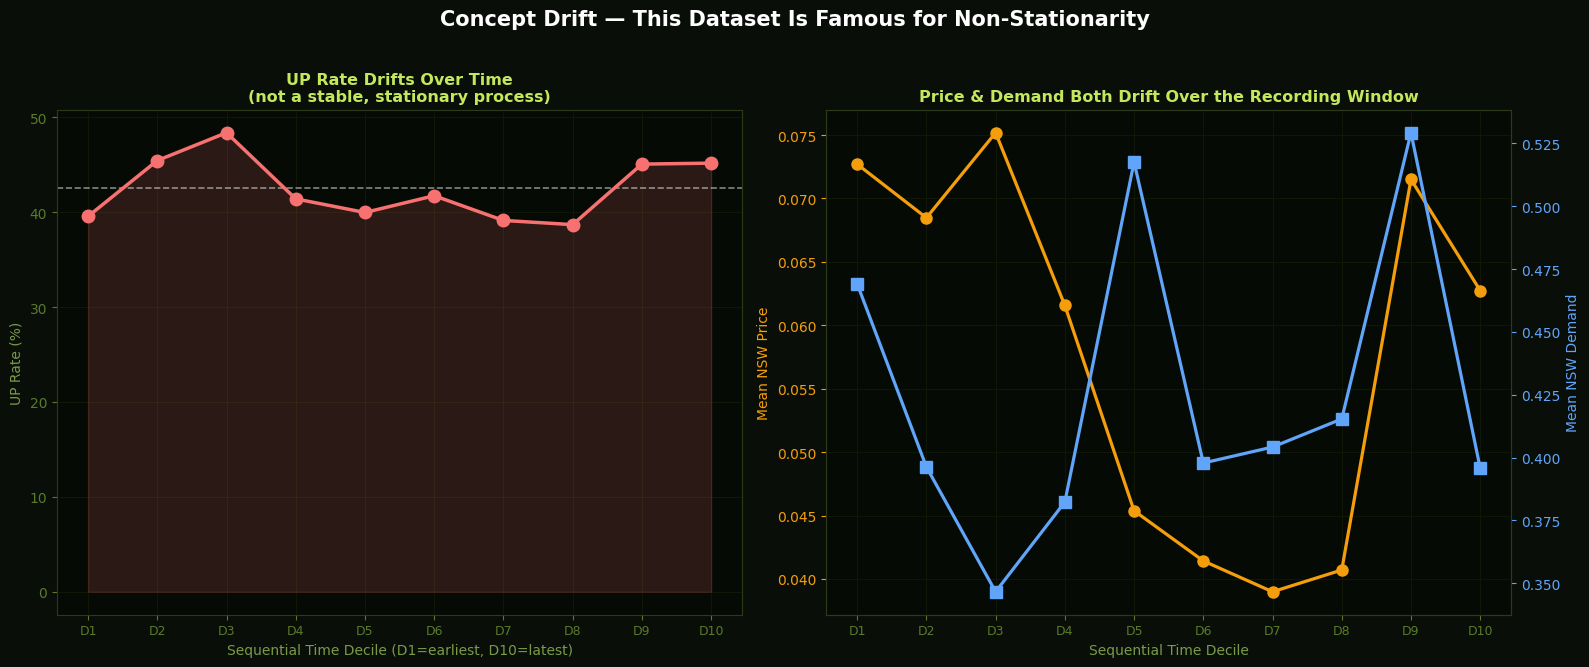

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Concept Drift — This Dataset Is Famous for Non-Stationarity', fontsize=15, fontweight='bold', color='white', y=1.02)

# 1. UP rate over sequential time deciles
ax = axes[0]
decile_up = df.groupby('time_decile', observed=True)['class_enc'].mean()*100
ax.plot(range(10), decile_up.values, 'o-', color=RED, lw=2.5, ms=9, zorder=5)
ax.fill_between(range(10), decile_up.values, alpha=0.15, color=RED)
ax.axhline(42.5, color='white', lw=1.2, ls='--', alpha=0.5)
ax.set_xticks(range(10)); ax.set_xticklabels([f'D{i+1}' for i in range(10)], fontsize=9)
ax.set_xlabel('Sequential Time Decile (D1=earliest, D10=latest)')
ax.set_ylabel('UP Rate (%)')
ax.set_title('UP Rate Drifts Over Time\n(not a stable, stationary process)', fontweight='bold', fontsize=11.5)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. nswprice and nswdemand mean over time deciles (dual axis)
ax = axes[1]
decile_price = df.groupby('time_decile', observed=True)['nswprice'].mean()
decile_demand = df.groupby('time_decile', observed=True)['nswdemand'].mean()
ax.plot(range(10), decile_price.values, 'o-', color=AMBER, lw=2.3, ms=8, label='Mean NSW Price', zorder=5)
ax.set_ylabel('Mean NSW Price', color=AMBER)
ax.tick_params(axis='y', colors=AMBER)
ax2b = ax.twinx()
ax2b.plot(range(10), decile_demand.values, 's-', color=BLUE, lw=2.3, ms=8, label='Mean NSW Demand', zorder=5)
ax2b.set_ylabel('Mean NSW Demand', color=BLUE)
ax2b.tick_params(axis='y', colors=BLUE)
ax.set_xticks(range(10)); ax.set_xticklabels([f'D{i+1}' for i in range(10)], fontsize=9)
ax.set_xlabel('Sequential Time Decile')
ax.set_title('Price & Demand Both Drift Over the Recording Window', fontweight='bold', fontsize=11.5)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('05_driftt.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 8. The NSW-VIC Interconnect <a id='8'></a>


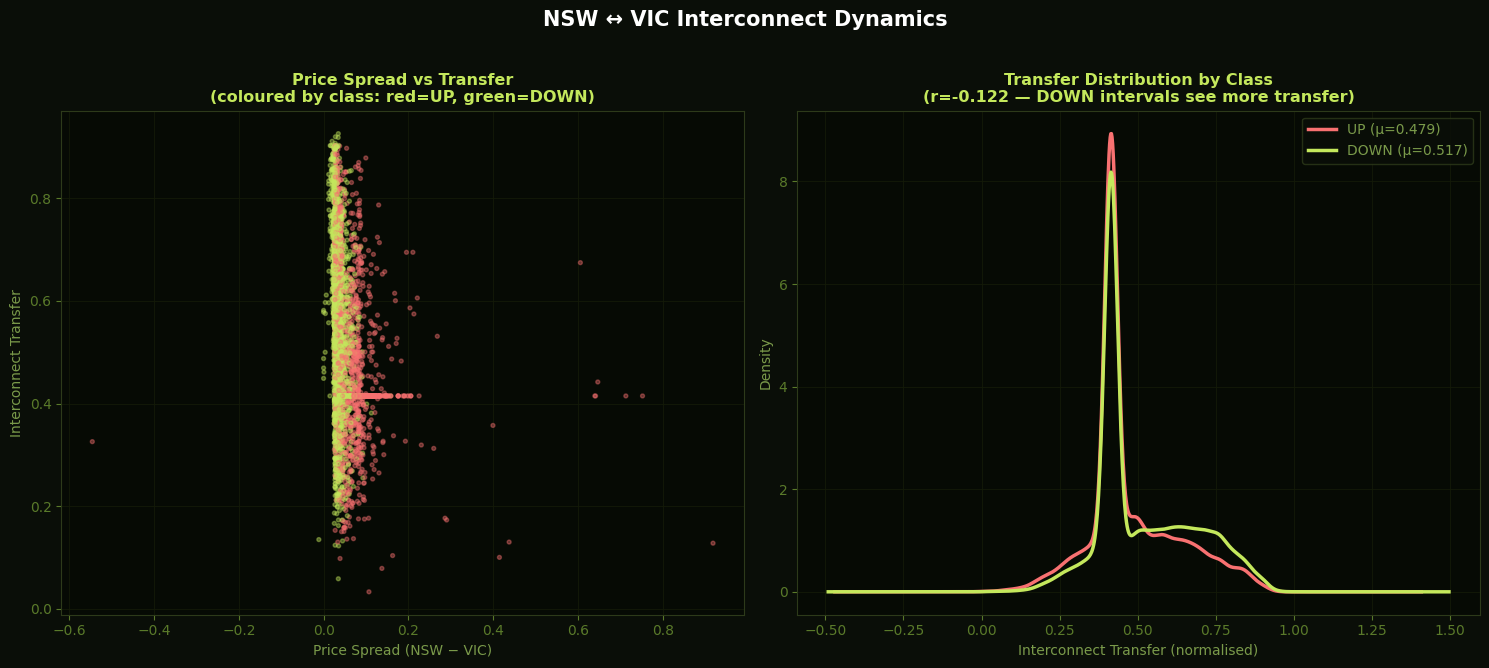

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('NSW ↔ VIC Interconnect Dynamics', fontsize=15, fontweight='bold', color='white', y=1.02)

# 1. Price spread vs transfer scatter
ax = axes[0]
sample = df.sample(5000, random_state=42)
sc = ax.scatter(sample['price_spread'], sample['transfer'], c=sample['class_enc'], cmap=CMAP_GRID, s=8, alpha=0.4, zorder=3)
ax.set_xlabel('Price Spread (NSW − VIC)'); ax.set_ylabel('Interconnect Transfer')
ax.set_title('Price Spread vs Transfer\n(coloured by class: red=UP, green=DOWN)', fontweight='bold', fontsize=11.5)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Transfer vs class
ax = axes[1]
for cls, color in CLASS_PAL.items():
    sub = df[df['class']==cls]['transfer']
    sub.plot.kde(ax=ax, color=color, lw=2.5, label=f'{cls} (μ={sub.mean():.3f})')
ax.set_xlabel('Interconnect Transfer (normalised)'); ax.set_ylabel('Density')
ax.set_title(f'Transfer Distribution by Class\n(r={df["transfer"].corr(df["class_enc"]):.3f} — DOWN intervals see more transfer)', fontweight='bold', fontsize=11.5)
ax.legend(fontsize=10); ax.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('06_interconnect.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 9. Correlation Heatmap <a id='9'></a>


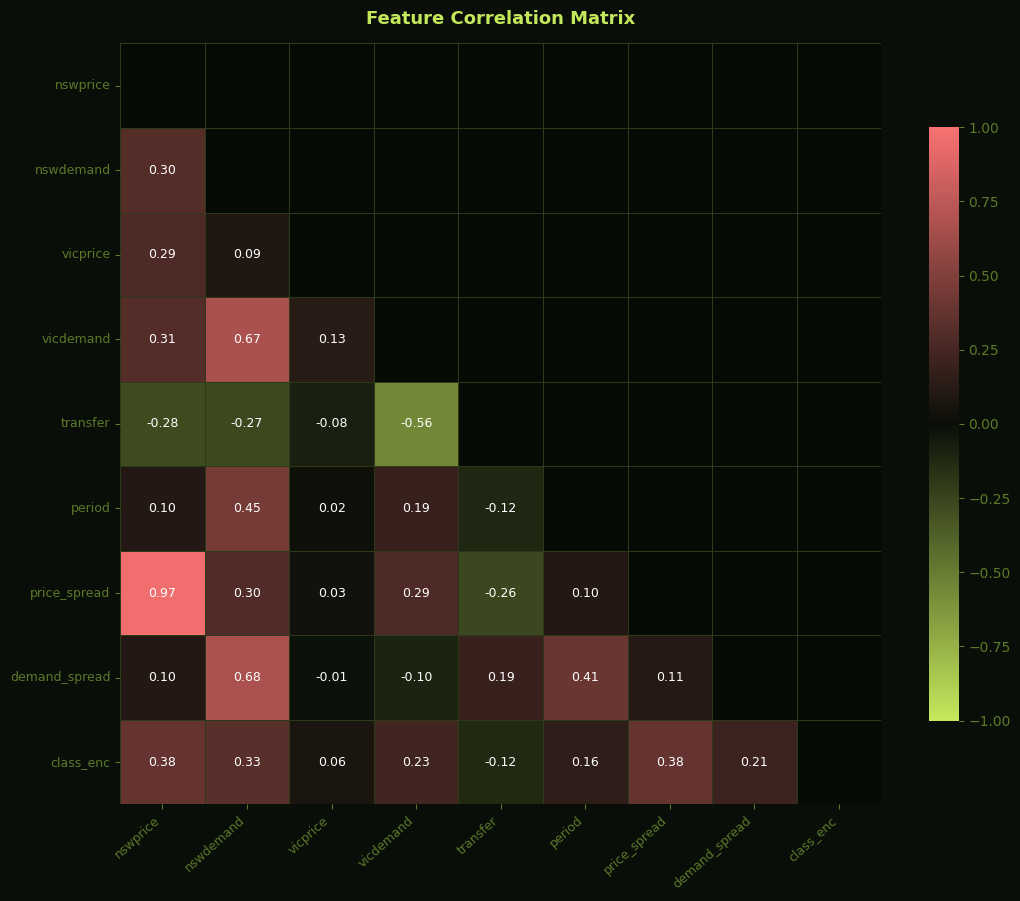

Top correlates with class_enc:
nswprice         0.379
price_spread     0.378
nswdemand        0.334
vicdemand        0.234
demand_spread    0.215
period           0.155
transfer        -0.122
vicprice         0.065
Name: class_enc, dtype: float64


In [11]:
corr_cols = ['nswprice','nswdemand','vicprice','vicdemand','transfer','period',
             'price_spread','demand_spread','class_enc']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor(BG)
sns.heatmap(corr, mask=mask, cmap=CMAP_GRID, vmin=-1, vmax=1, annot=True, fmt='.2f',
            linewidths=0.5, linecolor=GRID, annot_kws={'size':9,'color':'white'},
            cbar_kws={'shrink':0.78}, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=42, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('07_correlation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Top correlates with class_enc:')
print(corr['class_enc'].drop('class_enc').sort_values(key=abs, ascending=False).round(3))


## 10. ML Classifiers — Predicting Price Direction <a id='10'></a>


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# CRITICAL: chronological split (not random shuffle) — this is time-series data with known
# concept drift, so a random split would leak future information into training
split_point = int(len(df) * 0.8)
df_sorted = df.sort_values('time_index')
feat_cols = ['nswprice','nswdemand','vicprice','vicdemand','transfer','period','day']
train_df = df_sorted.iloc[:split_point]
test_df  = df_sorted.iloc[split_point:]
X_train, y_train = train_df[feat_cols], train_df['class_enc']
X_test,  y_test  = test_df[feat_cols],  test_df['class_enc']

print(f'Train: {len(X_train):,} (chronologically earliest 80%)')
print(f'Test:  {len(X_test):,} (chronologically latest 20% — true forward-looking test)')

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, proba)
    results[name] = {'model':model,'preds':preds,'proba':proba,'auc':auc}
    print(f'\n=== {name} ===')
    print(classification_report(y_test, preds, target_names=['DOWN','UP']))
    print(f'ROC-AUC: {auc:.4f}')

print('\n⚠️  Note the chronological (not random) split — this is the only honest way to evaluate')
print('   a model on data known to exhibit concept drift; a random split would overstate performance.')


Train: 36,249 (chronologically earliest 80%)
Test:  9,063 (chronologically latest 20% — true forward-looking test)

=== Logistic Regression ===
              precision    recall  f1-score   support

        DOWN       0.85      0.73      0.79      4974
          UP       0.72      0.84      0.78      4089

    accuracy                           0.78      9063
   macro avg       0.79      0.79      0.78      9063
weighted avg       0.79      0.78      0.78      9063

ROC-AUC: 0.8585

=== Random Forest ===
              precision    recall  f1-score   support

        DOWN       0.89      0.58      0.70      4974
          UP       0.64      0.92      0.75      4089

    accuracy                           0.73      9063
   macro avg       0.77      0.75      0.73      9063
weighted avg       0.78      0.73      0.73      9063

ROC-AUC: 0.8552

=== Gradient Boosting ===
              precision    recall  f1-score   support

        DOWN       0.92      0.56      0.69      4974
          U

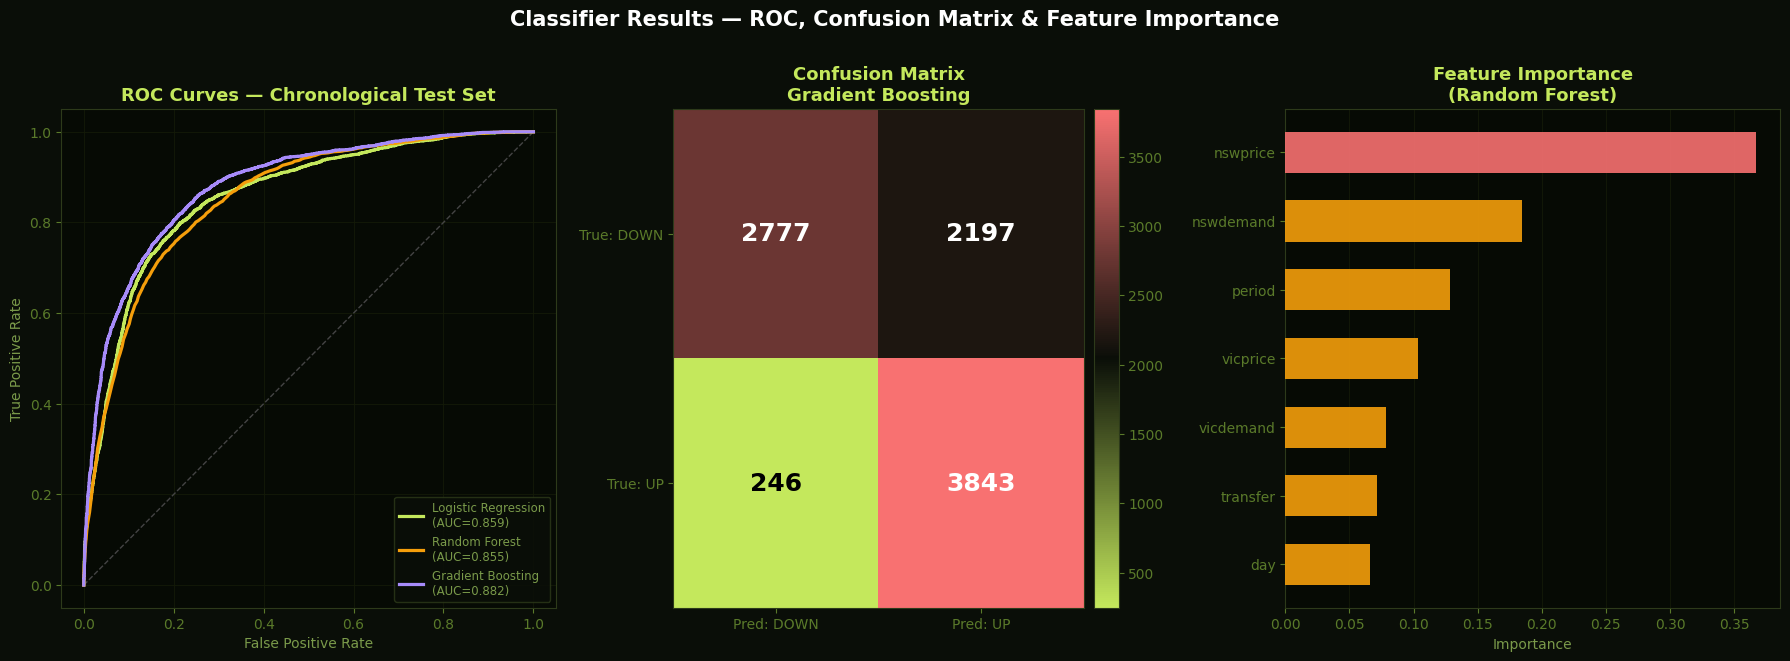

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Classifier Results — ROC, Confusion Matrix & Feature Importance', fontsize=15, fontweight='bold', color='white', y=1.01)

model_cols = [LIME, AMBER, PURPLE]
ax = axes[0]
ax.plot([0,1],[0,1], color='#444', lw=1, ls='--')
for (name, res), color in zip(results.items(), model_cols):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax.plot(fpr, tpr, color=color, lw=2.3, label=f'{name}\n(AUC={res["auc"]:.3f})')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Chronological Test Set', fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(True, zorder=0)

ax2 = axes[1]
best_name = max(results, key=lambda k: results[k]['auc'])
cm = confusion_matrix(y_test, results[best_name]['preds'])
im = ax2.imshow(cm, cmap=CMAP_GRID, aspect='auto')
ax2.set_xticks([0,1]); ax2.set_xticklabels(['Pred: DOWN','Pred: UP'], fontsize=10)
ax2.set_yticks([0,1]); ax2.set_yticklabels(['True: DOWN','True: UP'], fontsize=10)
ax2.set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=18, fontweight='bold',
                 color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.colorbar(im, ax=ax2, pad=0.02)

ax3 = axes[2]
rf = results['Random Forest']['model']
imp = pd.Series(rf.feature_importances_, index=feat_cols).sort_values()
colors_fi = [RED if v==imp.max() else AMBER for v in imp.values]
ax3.barh(range(len(imp)), imp.values, color=colors_fi, height=0.6, zorder=3, alpha=0.9)
ax3.set_yticks(range(len(imp))); ax3.set_yticklabels(imp.index, fontsize=10)
ax3.set_xlabel('Importance'); ax3.set_title('Feature Importance\n(Random Forest)', fontweight='bold')
ax3.grid(axis='x', zorder=0); ax3.set_axisbelow(True)

plt.tight_layout()
plt.savefig('08_ml_results.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 11. Key Takeaways <a id='11'></a>


<div style="background:#0a0e08;border-radius:12px;padding:0;font-family:'Courier New',monospace;border:1px solid #2d3a1a;overflow:hidden;">
  <div style="background:#060a04;padding:10px 24px;border-bottom:1px solid #2d3a1a;">
    <span style="color:#c4e85c;font-size:0.7rem;letter-spacing:2px;">▌ ELECTRICITY_MARKET_ANALYSIS.log — KEY FINDINGS</span>
  </div>
  <div style="padding:22px 28px;display:grid;grid-template-columns:1fr 1fr;gap:12px;">
    <div style="border-left:2px solid #c4e85c;padding-left:14px;">
      <div style="color:#c4e85c;font-size:0.65rem;letter-spacing:3px;margin-bottom:8px;">[DEMAND CYCLE]</div>
      <ul style="color:#7a9a4a;margin:0;padding-left:0;list-style:none;line-height:2;font-size:0.8rem;">
        <li><span style="color:#c4e85c;">&gt;</span> UP-rate swings from 5% at 3am to 68% at 9am — a clear business-hours demand ramp</li>
        <li><span style="color:#c4e85c;">&gt;</span> NSW demand curve tracks the UP-rate pattern almost exactly across the day</li>
        <li><span style="color:#c4e85c;">&gt;</span> Monday (48.0% UP) is the highest-volatility weekday; Saturday (39.5%) the calmest</li>
      </ul>
    </div>
    <div style="border-left:2px solid #f59e0b;padding-left:14px;">
      <div style="color:#f59e0b;font-size:0.65rem;letter-spacing:3px;margin-bottom:8px;">[TOP PREDICTORS]</div>
      <ul style="color:#7a9a4a;margin:0;padding-left:0;list-style:none;line-height:2;font-size:0.8rem;">
        <li><span style="color:#f59e0b;"></span> nswprice (r=0.379) and nswdemand (r=0.334) dominate — NSW-side signals matter most</li>
        <li><span style="color:#f59e0b;"></span> vicprice is nearly uninformative alone (r=0.065) — Victoria price barely moves</li>
        <li><span style="color:#f59e0b;"></span> Interconnect transfer is negatively correlated (r=−0.122) — more transfer relieves NSW pressure</li>
      </ul>
    </div>
    <div style="border-left:2px solid #f87171;padding-left:14px;">
      <div style="color:#f87171;font-size:0.65rem;letter-spacing:3px;margin-bottom:8px;">[CONCEPT DRIFT CONFIRMED]</div>
      <ul style="color:#7a9a4a;margin:0;padding-left:0;list-style:none;line-height:2;font-size:0.8rem;">
        <li><span style="color:#f87171;">!</span> UP-rate is NOT stable across sequential time deciles — it drifts meaningfully</li>
        <li><span style="color:#f87171;">!</span> Mean nswprice and nswdemand both shift across the recording window</li>
        <li><span style="color:#f87171;">!</span> This is exactly why this dataset is a standard concept-drift benchmark in stream-mining research</li>
      </ul>
    </div>
    <div style="border-left:2px solid #60a5fa;padding-left:14px;">
      <div style="color:#60a5fa;font-size:0.65rem;letter-spacing:3px;margin-bottom:8px;">[METHODOLOGY]</div>
      <ul style="color:#7a9a4a;margin:0;padding-left:0;list-style:none;line-height:2;font-size:0.8rem;">
        <li><span style="color:#60a5fa;">~</span> Train/test split is chronological, not random — required given confirmed drift</li>
        <li><span style="color:#60a5fa;">~</span> A random shuffle split would leak future market regimes into training and overstate accuracy</li>
        <li><span style="color:#60a5fa;">~</span> ROC-AUC reported in Section 10 reflects genuine forward-looking generalisation</li>
      </ul>
    </div>

  </div>
  <div style="background:#060a04;border-top:1px solid #2d3a1a;padding:8px 28px;">
    <span style="color:#2d3a1a;font-size:0.65rem;">⚠ Historical market data — not a live trading signal. Author: Muhammad Aamir · NSW/VIC Electricity Market · Kaggle Notebook</span>
  </div>
</div>
